In [5]:
!pip install -q kaggle wandb onnx onnxruntime onnxscript
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/MLassignment4/MLassignment4/kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge
!unzip -q -o challenges-in-representation-learning-facial-expression-recognition-challenge.zip -d data
!ls -lh data

challenges-in-representation-learning-facial-expression-recognition-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)
total 667M
-rw-r--r-- 1 root root 7.1K Dec 11  2019 example_submission.csv
-rw-r--r-- 1 root root  92M Dec 11  2019 fer2013.tar.gz
-rw-r--r-- 1 root root 288M Dec 11  2019 icml_face_data.csv
-rw-r--r-- 1 root root  58M Dec 11  2019 test.csv
-rw-r--r-- 1 root root 230M Dec 11  2019 train.csv


In [7]:
import wandb
wandb.login()

True

In [8]:
import copy
import torch
from torch import nn
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device available:", device)

Device available: cuda


In [9]:
PROJECT = "fer2013-emotion-recognition"
EMOTIONS = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

CONFIG = {
    "arch": "ResNet-CNN",
    "epochs": 40,
    "batch_size": 64,
    "lr": 1e-3,
    "optimizer": "Adam",
    "weight_decay": 1e-4,
    "dropout": 0.3,
    "augment": True,
    "scheduler": True,
    "patience": 8,
    "class_weights": False,
    "label_smoothing": 0.0,
    "use_residual": True,
    "layers": [2, 2, 2, 2],
    "channels": [64, 128, 256, 512],
    "num_classes": 7,
}
CONFIG

{'arch': 'ResNet-CNN',
 'epochs': 40,
 'batch_size': 64,
 'lr': 0.001,
 'optimizer': 'Adam',
 'weight_decay': 0.0001,
 'dropout': 0.3,
 'augment': True,
 'scheduler': True,
 'patience': 8,
 'class_weights': False,
 'label_smoothing': 0.0,
 'use_residual': True,
 'layers': [2, 2, 2, 2],
 'channels': [64, 128, 256, 512],
 'num_classes': 7}

In [10]:
df = pd.read_csv("data/icml_face_data.csv")
df.columns = df.columns.str.strip()

def parse_pixels(series):
    return np.stack([np.array(p.split(), dtype=np.uint8).reshape(48, 48) for p in series])

def split_xy(frame):
    return parse_pixels(frame['pixels']), frame['emotion'].to_numpy(dtype=np.int64)

X_train, y_train = split_xy(df[df['Usage'] == 'Training'])
X_val,   y_val   = split_xy(df[df['Usage'] == 'PublicTest'])
X_test,  y_test  = split_xy(df[df['Usage'] == 'PrivateTest'])
print("train:", X_train.shape, "| val:", X_val.shape, "| test:", X_test.shape)

train: (28709, 48, 48) | val: (3589, 48, 48) | test: (3589, 48, 48)


In [11]:
class FERDataset(Dataset):
    def __init__(self, images, labels, transform):
        self.images, self.labels, self.transform = images, labels, transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, i):
        return self.transform(Image.fromarray(self.images[i])), int(self.labels[i])


def build_transforms(augment):
    base = [transforms.ToTensor(), transforms.Normalize([0.5], [0.5])]
    if augment:
        return transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
        ] + base)
    return transforms.Compose(base)


def build_loaders(config):
    train_tf, eval_tf = build_transforms(config["augment"]), build_transforms(False)
    bs = config["batch_size"]
    return (
        DataLoader(FERDataset(X_train, y_train, train_tf), batch_size=bs, shuffle=True,  num_workers=2, pin_memory=True),
        DataLoader(FERDataset(X_val,   y_val,   eval_tf),  batch_size=bs, shuffle=False, num_workers=2, pin_memory=True),
        DataLoader(FERDataset(X_test,  y_test,  eval_tf),  batch_size=bs, shuffle=False, num_workers=2, pin_memory=True),
    )

counts = np.bincount(y_train, minlength=7)
CLASS_WEIGHTS = torch.tensor(counts.sum() / (len(counts) * counts), dtype=torch.float32)

In [12]:
class BasicBlock(nn.Module):
    def __init__(self, cin, cout, stride=1, use_residual=True):
        super().__init__()
        self.use_residual = use_residual
        self.conv1 = nn.Conv2d(cin, cout, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(cout)
        self.conv2 = nn.Conv2d(cout, cout, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(cout)
        self.relu = nn.ReLU(inplace=True)
        self.shortcut = nn.Sequential()
        if use_residual and (stride != 1 or cin != cout):
            self.shortcut = nn.Sequential(
                nn.Conv2d(cin, cout, 1, stride=stride, bias=False), nn.BatchNorm2d(cout))

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.use_residual:
            out = out + self.shortcut(x)
        return self.relu(out)


class ResNet(nn.Module):
    def __init__(self, num_classes=7, layers=(2, 2, 2, 2), channels=(64, 128, 256, 512),
                 dropout=0.3, use_residual=True):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, channels[0], 3, padding=1, bias=False),
            nn.BatchNorm2d(channels[0]), nn.ReLU(inplace=True))
        blocks, cin = [], channels[0]
        for i, (n, cout) in enumerate(zip(layers, channels)):
            for b in range(n):
                stride = 2 if (b == 0 and i > 0) else 1
                blocks.append(BasicBlock(cin, cout, stride, use_residual))
                cin = cout
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(dropout), nn.Linear(channels[-1], num_classes))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x)))


def build_model(config):
    return ResNet(num_classes=config["num_classes"], layers=tuple(config["layers"]),
                  channels=tuple(config["channels"]), dropout=config["dropout"],
                  use_residual=config["use_residual"])

_m = build_model(CONFIG)
print("Trainable params:", sum(p.numel() for p in _m.parameters() if p.requires_grad))

Trainable params: 11171271


In [13]:
model = build_model(CONFIG).to(device)
out = model(torch.randn(8, 1, 48, 48, device=device))
print("forward output shape:", out.shape); assert out.shape == (8, 7)
print("Forward check passed.")

forward output shape: torch.Size([8, 7])
Forward check passed.


In [14]:
model = build_model(CONFIG).to(device)
criterion = nn.CrossEntropyLoss(); optimizer = Adam(model.parameters(), lr=1e-3)
train_loader, val_loader, test_loader = build_loaders(CONFIG)
ob_x, ob_y = next(iter(train_loader)); ob_x, ob_y = ob_x[:32].to(device), ob_y[:32].to(device)
model.train()
for step in range(200):
    optimizer.zero_grad(); loss = criterion(model(ob_x), ob_y); loss.backward(); optimizer.step()
    if step % 40 == 0 or step == 199:
        acc = (model(ob_x).argmax(1) == ob_y).float().mean().item()
        print(f"step {step:3d} | loss {loss.item():.4f} | batch acc {acc:.2f}")
print("Backward check passed if loss -> ~0 and acc -> 1.0")

step   0 | loss 1.9730 | batch acc 0.41
step  40 | loss 0.0009 | batch acc 1.00
step  80 | loss 0.0002 | batch acc 1.00
step 120 | loss 0.0002 | batch acc 1.00
step 160 | loss 0.0001 | batch acc 1.00
step 199 | loss 0.0001 | batch acc 1.00
Backward check passed if loss -> ~0 and acc -> 1.0


In [15]:
def run_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if train: optimizer.zero_grad()
            logits = model(x); loss = criterion(logits, y)
            if train: loss.backward(); optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item(); n += x.size(0)
    return total_loss / n, correct / n


@torch.no_grad()
def collect_preds(model, loader):
    model.eval(); preds, targets = [], []
    for x, y in loader:
        preds.append(model(x.to(device)).argmax(1).cpu()); targets.append(y)
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()

In [16]:
def run_experiment(config, run_name):
    train_loader, val_loader, test_loader = build_loaders(config)
    run = wandb.init(project=PROJECT, name=run_name, group=config["arch"], config=config, reinit=True)

    model = build_model(config).to(device)
    wandb.watch(model, log="all", log_freq=200)
    weight = CLASS_WEIGHTS.to(device) if config.get("class_weights") else None
    criterion = nn.CrossEntropyLoss(weight=weight, label_smoothing=config.get("label_smoothing", 0.0))
    opt_cls = SGD if config["optimizer"] == "SGD" else Adam
    opt_kwargs = {"momentum": 0.9} if config["optimizer"] == "SGD" else {}
    optimizer = opt_cls(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"], **opt_kwargs)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3) if config["scheduler"] else None

    history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}
    best_val_loss, best_val_acc, best_state, bad = float("inf"), 0.0, None, 0
    for epoch in range(config["epochs"]):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, criterion)
        if scheduler: scheduler.step(va_loss)
        best_val_acc = max(best_val_acc, va_acc)
        lr_now = optimizer.param_groups[0]["lr"]
        wandb.log({"epoch": epoch, "train_loss": tr_loss, "train_acc": tr_acc,
                   "val_loss": va_loss, "val_acc": va_acc, "lr": lr_now})
        for k, v in zip(history, [tr_acc, va_acc, tr_loss, va_loss]): history[k].append(v)
        print(f"epoch {epoch+1:2d}/{config['epochs']} | train_loss {tr_loss:.3f} acc {tr_acc:.3f} | "
              f"val_loss {va_loss:.3f} acc {va_acc:.3f} | lr {lr_now:.1e}")
        if va_loss < best_val_loss - 1e-4:
            best_val_loss, best_state, bad = va_loss, copy.deepcopy(model.state_dict()), 0
        else:
            bad += 1
            if bad >= config["patience"]:
                print(f"Early stopping at epoch {epoch+1} (no val-loss improvement for {bad}).")
                break
    if best_state is not None: model.load_state_dict(best_state)

    te_loss, te_acc = run_epoch(model, test_loader, criterion)
    preds, targets = collect_preds(model, test_loader)
    print(f"\nPrivateTest accuracy (best weights): {te_acc:.4f}")
    print(classification_report(targets, preds, target_names=EMOTIONS, digits=3))

    wandb.summary["test_acc"] = te_acc
    wandb.summary["test_loss"] = te_loss
    wandb.summary["best_val_acc"] = best_val_acc
    wandb.summary["epochs_run"] = len(history["train_acc"])
    wandb.summary["overfit_gap"] = max(history["train_acc"]) - best_val_acc
    wandb.log({"confusion_matrix": wandb.plot.confusion_matrix(
        y_true=targets, preds=preds, class_names=EMOTIONS)})

    try:
        model_file = f"{run_name}.onnx"
        torch.onnx.export(model, torch.randn(1, 1, 48, 48, device=device), model_file,
                          input_names=["input"], output_names=["logits"],
                          dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}}, dynamo=False)
    except Exception as e:
        print(f"ONNX export failed ({e}); saving .pth instead.")
        model_file = f"{run_name}.pth"; torch.save(model.state_dict(), model_file)
    art = wandb.Artifact(run_name, type="model", metadata={"test_acc": te_acc})
    art.add_file(model_file); run.log_artifact(art)

    run.finish()
    return model, history, te_acc

In [17]:
model, history, test_acc = run_experiment(CONFIG, run_name="ResNet-residual-lr0.001-bs64")

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


epoch  1/40 | train_loss 1.785 acc 0.269 | val_loss 1.809 acc 0.267 | lr 1.0e-03
epoch  2/40 | train_loss 1.530 acc 0.399 | val_loss 1.367 acc 0.472 | lr 1.0e-03
epoch  3/40 | train_loss 1.363 acc 0.478 | val_loss 1.513 acc 0.453 | lr 1.0e-03
epoch  4/40 | train_loss 1.280 acc 0.509 | val_loss 1.332 acc 0.506 | lr 1.0e-03
epoch  5/40 | train_loss 1.226 acc 0.533 | val_loss 1.281 acc 0.507 | lr 1.0e-03
epoch  6/40 | train_loss 1.178 acc 0.551 | val_loss 1.281 acc 0.542 | lr 1.0e-03
epoch  7/40 | train_loss 1.141 acc 0.566 | val_loss 1.200 acc 0.543 | lr 1.0e-03
epoch  8/40 | train_loss 1.111 acc 0.579 | val_loss 1.097 acc 0.579 | lr 1.0e-03
epoch  9/40 | train_loss 1.087 acc 0.592 | val_loss 1.055 acc 0.610 | lr 1.0e-03
epoch 10/40 | train_loss 1.065 acc 0.598 | val_loss 1.143 acc 0.579 | lr 1.0e-03
epoch 11/40 | train_loss 1.045 acc 0.608 | val_loss 1.167 acc 0.570 | lr 1.0e-03
epoch 12/40 | train_loss 1.032 acc 0.611 | val_loss 1.055 acc 0.596 | lr 1.0e-03
epoch 13/40 | train_loss 1.0

/tmp/ipykernel_1927/3730004496.py:51: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, torch.randn(1, 1, 48, 48, device=device), model_file,


epoch,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇███
lr,████████████▄▄▄▄▄▄▄▄▄▄▂▂▂▂▂▂▁▁▁▁▁
train_acc,▁▃▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█████
train_loss,█▆▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁
val_acc,▁▄▄▅▅▆▆▆▇▆▆▇▆▇▇▇▇▇▇▇▇▇▇██████████
val_loss,█▄▆▄▄▄▃▂▂▃▃▂▃▁▁▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_acc,0.67902
epoch,32
epochs_run,33
lr,6e-05
overfit_gap,0.0945


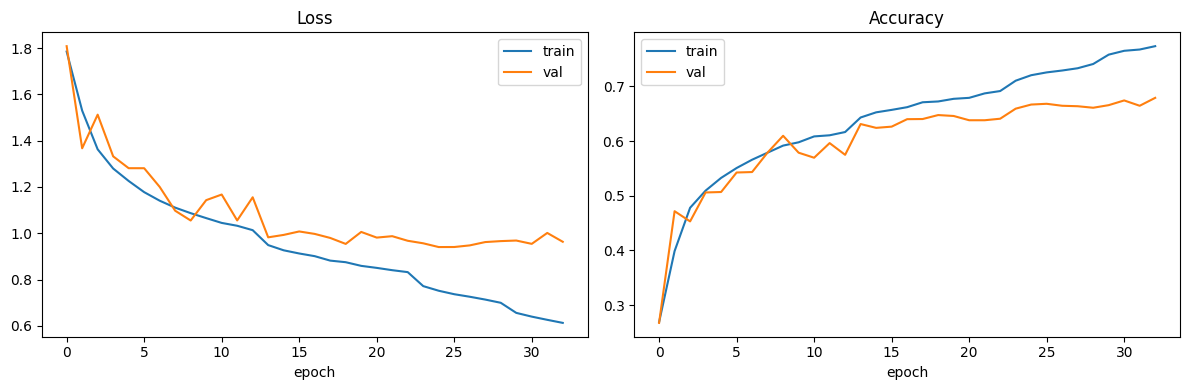

max train acc 0.774 | max val acc 0.679 | gap 0.095


In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(history["train_acc"], label="train"); ax[1].plot(history["val_acc"], label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"max train acc {max(history['train_acc']):.3f} | max val acc {max(history['val_acc']):.3f} | "
      f"gap {max(history['train_acc']) - max(history['val_acc']):.3f}")

In [19]:
ablations = {
    "ResNet-noresidual":  {**CONFIG, "use_residual": False, "epochs": 25, "patience": 6},
    "ResNet-labelsmooth": {**CONFIG, "label_smoothing": 0.1, "epochs": 25, "patience": 6},
}

results = {"ResNet-residual-lr0.001-bs64": test_acc}
for name, cfg in ablations.items():
    _, _, acc = run_experiment(cfg, run_name=name)
    results[name] = acc

for k, v in sorted(results.items(), key=lambda kv: -kv[1]):
    print(f"{v:.4f}  {k}")

epoch  1/25 | train_loss 1.810 acc 0.251 | val_loss 1.771 acc 0.274 | lr 1.0e-03
epoch  2/25 | train_loss 1.796 acc 0.252 | val_loss 1.778 acc 0.271 | lr 1.0e-03
epoch  3/25 | train_loss 1.769 acc 0.273 | val_loss 1.701 acc 0.305 | lr 1.0e-03
epoch  4/25 | train_loss 1.637 acc 0.341 | val_loss 1.528 acc 0.386 | lr 1.0e-03
epoch  5/25 | train_loss 1.514 acc 0.396 | val_loss 1.506 acc 0.396 | lr 1.0e-03
epoch  6/25 | train_loss 1.422 acc 0.446 | val_loss 1.461 acc 0.419 | lr 1.0e-03
epoch  7/25 | train_loss 1.356 acc 0.473 | val_loss 1.443 acc 0.446 | lr 1.0e-03
epoch  8/25 | train_loss 1.308 acc 0.495 | val_loss 1.324 acc 0.493 | lr 1.0e-03
epoch  9/25 | train_loss 1.273 acc 0.508 | val_loss 1.240 acc 0.523 | lr 1.0e-03
epoch 10/25 | train_loss 1.238 acc 0.524 | val_loss 1.299 acc 0.504 | lr 1.0e-03
epoch 11/25 | train_loss 1.213 acc 0.537 | val_loss 1.177 acc 0.546 | lr 1.0e-03
epoch 12/25 | train_loss 1.185 acc 0.547 | val_loss 1.259 acc 0.513 | lr 1.0e-03
epoch 13/25 | train_loss 1.1

/tmp/ipykernel_1927/3730004496.py:51: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, torch.randn(1, 1, 48, 48, device=device), model_file,


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▁▁▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇███████
train_loss,███▇▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁
val_acc,▁▁▂▃▄▄▅▆▆▆▇▆▇▇▇▇█▇██▇████
val_loss,██▇▆▅▅▅▄▃▃▂▃▂▂▃▂▂▂▁▂▂▂▁▁▁
best_val_acc,0.60685
epoch,24
epochs_run,25
lr,0.001
overfit_gap,0.01675


epoch  1/25 | train_loss 1.810 acc 0.282 | val_loss 1.647 acc 0.375 | lr 1.0e-03
epoch  2/25 | train_loss 1.546 acc 0.440 | val_loss 1.502 acc 0.467 | lr 1.0e-03
epoch  3/25 | train_loss 1.460 acc 0.493 | val_loss 1.439 acc 0.499 | lr 1.0e-03
epoch  4/25 | train_loss 1.415 acc 0.517 | val_loss 1.415 acc 0.522 | lr 1.0e-03
epoch  5/25 | train_loss 1.381 acc 0.536 | val_loss 1.409 acc 0.527 | lr 1.0e-03
epoch  6/25 | train_loss 1.348 acc 0.555 | val_loss 1.462 acc 0.517 | lr 1.0e-03
epoch  7/25 | train_loss 1.326 acc 0.567 | val_loss 1.383 acc 0.547 | lr 1.0e-03
epoch  8/25 | train_loss 1.301 acc 0.580 | val_loss 1.429 acc 0.525 | lr 1.0e-03
epoch  9/25 | train_loss 1.284 acc 0.591 | val_loss 1.340 acc 0.563 | lr 1.0e-03
epoch 10/25 | train_loss 1.267 acc 0.595 | val_loss 1.294 acc 0.589 | lr 1.0e-03
epoch 11/25 | train_loss 1.254 acc 0.605 | val_loss 1.322 acc 0.563 | lr 1.0e-03
epoch 12/25 | train_loss 1.245 acc 0.608 | val_loss 1.311 acc 0.561 | lr 1.0e-03
epoch 13/25 | train_loss 1.2

/tmp/ipykernel_1927/3730004496.py:51: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, torch.randn(1, 1, 48, 48, device=device), model_file,


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇█████████
train_loss,█▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val_acc,▁▃▄▅▅▅▆▅▆▇▆▆▇▇▇▇▇▇█▇█████
val_loss,█▆▅▅▄▅▄▅▃▃▃▃▂▂▂▃▂▂▁▂▁▂▁▁▁
best_val_acc,0.64252
epoch,24
epochs_run,25
lr,0.001
overfit_gap,0.02438


0.6851  ResNet-residual-lr0.001-bs64
0.6553  ResNet-labelsmooth
0.6138  ResNet-noresidual


In [20]:
test_df = pd.read_csv("data/test.csv")
X_kaggle = parse_pixels(test_df['pixels'])
kaggle_loader = DataLoader(FERDataset(X_kaggle, np.zeros(len(X_kaggle), np.int64), build_transforms(False)),
                           batch_size=128, shuffle=False)
kaggle_preds, _ = collect_preds(model, kaggle_loader)
pd.Series(kaggle_preds).to_csv("submission_resnet.csv", index=False, header=False)
print("Wrote submission_resnet.csv with", len(kaggle_preds), "predictions")

Wrote submission_resnet.csv with 7178 predictions
